# Amini Canopy or Crop Challenge — From First Baseline to a Tuned Model

A guided, beginner-friendly walkthrough of a complete [Zindi](https://zindi.world)
competition workflow, showing how a solution improves **one principled experiment
at a time**.

## Problem Description

The [Amini Canopy or Crop Challenge](https://zindi.world/competitions/amini-canopy-or-crop-challenge)
asks us to classify land-cover pixels into three classes:

- **forest tree cover** (`Target = 0`)
- **cocoa crops** (`Target = 1`)
- **palm plantations** (`Target = 2`)

using multi-year time series derived from **Sentinel-2** satellite imagery.

## Data Description

The data is in **long format**: each row is *one pixel observed at one point in
time*. Every pixel (`ID`) is observed at many timestamps from 2021 onward.

- Columns: `ID, time`, 13 spectral bands (`Green, Blue, RED, NIR, SWIR1, SWIR2,
  Red_Edge, Aerosols, Red_Edge_2, Red_Edge_3, Red_Edge_4, Water_vapor, Cirrus`),
  4 provided spectral indices (`NDVI, NDMI, NDWI, CI`), and `Target` (train only).
- The data has **substantial missing values** — entire timestamps can be empty —
  so gap-filling and aggregation strategy matter.
- Submissions are CSVs with columns `ID,Target`, **one row per test pixel**.

## Entry Contributors

> Ramsey Ith Njema ([@rnjema](https://github.com/rnjema))
>
> Companion notebook for the *Zindi September Study Jam* session 
> [event page](https://luma.com/h79sb3iz) ·
> [discussion thread](https://zindi.world/competitions/amini-canopy-or-crop-challenge-september-studyjam/discussions/34804)

## How this notebook teaches experimentation

Competitive data science is not about finding one magic model, it is usually about
running **methodical, versioned experiments** where you change/ablate *one thing at a
time* and record the result. We will work through four (if the gods of time :-) will be so kind):

| Version | Change | Question it answers |
|---|---|---|
| **v0.1** | Baseline: multinomial logistic regression on summary stats | What does a simple linear model get? |
| **v0.2** | Same features, default Random Forest | Does model capacity help? |
| **v0.3** | Same model, engineered time-grid features | Does feature engineering help? |
| **v0.4** | Same features, Optuna-tuned XGBoost (CV objective) | Does principled tuning help? |

Every experiment is scored with the **same stratified K-fold protocol** and
recorded in an **Experiment Log**, so comparisons stay honest. When you iterate
on this notebook, keep extending the log; that habit is the real lesson, something that is gonna become so vital in your journey.


## 1. Setup 🛏 🧹

### Environment Preparation

Install and import the packages we need. On your own machine everything may
already be installed; on **Google Colab**, uncomment the install line below.


In [18]:
# On Google Colab, uncomment:
# %pip install -q spyndex optuna xgboost scikit-learn pandas matplotlib seaborn requests tqdm
try:
   import os
   import matplotlib
   import numpy as np 
   import sklearn
   import seaborn
   import optuna
   import xgboost
   import tqdm
   import torch
   import dotenv
   import zindi
except (ModuleNotFoundError, ImportError):
    !pip install -Uqqq spyndex optuna xgboost scikit-learn pandas matplotlib seaborn requests tqdm torch dotenv zindi
finally:
    import os
    import sys
    import warnings
    from datetime import datetime
    from pathlib import Path

    import matplotlib.pyplot as plt
    import numpy as np
    import optuna
    import pandas as pd
    import seaborn as sns
    import spyndex as spx
    import xgboost as xgb
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        ConfusionMatrixDisplay,
        accuracy_score,
        classification_report,
        confusion_matrix,
    )
    from sklearn.model_selection import (
        KFold,
        StratifiedKFold,
        cross_val_score,
        train_test_split,
    )
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_class_weight
    import torch
    from dotenv import load_dotenv
    if 'google.colab' in sys.modules:
        from google.colab import userdata

    warnings.filterwarnings("ignore")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sns.set_theme(style="whitegrid")

RANDOM_STATE = 42  # fix every seed so results are reproducible
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Loads environment variables into session
load_dotenv()

True

The cell below set ups and locates directories for data and all relevant artifacts


In [19]:
try:
    from amini_canopy.config import RAW_DATA_DIR, REPORTS_DIR
except ImportError:  # running outside the project, e.g. Google Colab
    RAW_DATA_DIR = Path("data/raw")
    REPORTS_DIR = Path("reports")

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR = REPORTS_DIR / "zindi_submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)


### Run-time flags

`QUICK_RUN` subsamples pixels and shortens tuning so you can dry-run the whole
notebook in minutes (useful live in a session or on a small laptop). Set it to
`False` for a real submission.


In [20]:
QUICK_RUN = False           # True = fast demo run on a subsample of pixels
N_SAMPLE_TRAIN_IDS = 2_000  # pixels kept per run when QUICK_RUN is True
N_OPTUNA_TRIALS = 10 if QUICK_RUN else 40
CV_FOLDS = 3 if QUICK_RUN else 5
TUNING_BOOST_ROUNDS = 200   # boosting rounds used inside the tuning objective


### Downloading Data ~ Zindi

Competition files live behind Zindi's API, which authenticates with an
**auth token** — the same `zus.v1.…` string your browser stores in
`localStorage` under `persist:primary → cookie → auth_token` after you log in
(see it yourself: DevTools → Application → Local Storage → `https://zindi.world`).

The flow below, in order of preference:

1. **Reuse** a token from a Colab secret (`ZINDI_AUTH_TOKEN`) or an environment
   variable — but only after checking it is **still active** against the
   competition endpoint.
2. If it is missing or expired, **log in interactively**: username in plain
   text, password masked with `getpass`. We sign in through the same
   `auth/signin` endpoint the website uses, with a browser User-Agent so the
   API treats the script like a normal web session. The sign-in response is
   exactly what the web app persists to `localStorage`, so we read the token
   straight from it — no copy-pasting from DevTools.
   (`token_from_localstorage_dump` is included for the day you *do* paste it
   from DevTools.)
3. The token is then exposed as `os.environ["ZINDI_AUTH_TOKEN"]` and
   `AUTH_TOKEN`, which every downstream download uses.

Security rules worth keeping for life: never hard-code or commit tokens or
passwords, never print a full token, and remember the token also proves you
**joined** the competition — downloads only work after accepting the rules on
the competition page. If the CSVs are already on disk, this whole flow is
skipped (so the notebook still runs fully offline).


In [21]:
from zindi.user import Zindian

In [22]:
COMPETITION_ID = "amini-canopy-or-crop-challenge-september-studyjam"

In [23]:
import json
from getpass import getpass

import requests
from tqdm import tqdm


ZINDI_API = "https://api.zindi.africa/v1"

# A plain requests session wearing a browser User-Agent, so the API sees a
# normal web session instead of an anonymous script.
ZINDI_SESSION = requests.Session()
ZINDI_SESSION.headers.update(
    {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36"
        )
    }
)


def get_stored_token():
    """Token from a Colab secret or the ZINDI_AUTH_TOKEN environment variable."""
    try:
        from google.colab import userdata  # only exists on Colab

        token = userdata.get("ZINDI_AUTH_TOKEN")
        if token:
            return token, "Colab secret"
    except Exception:
        pass  # not on Colab, or the secret is not defined
    token = os.environ.get("ZINDI_AUTH_TOKEN")
    if token:
        return token, "environment variable"
    return None, None


def mask_token(token):
    """Never print a full credential — show just enough to recognise it."""
    return f"{token[:7]}...{token[-3:]}"


def token_is_active(token):
    """Validate a token against a genuinely authenticated route.

    The public competition endpoint answers 200 even for bogus tokens, so we
    probe `my_participation`, which returns 401 'not authorized' unless the
    token is real and unexpired.
    """
    try:
        response = ZINDI_SESSION.get(
            f"{ZINDI_API}/competitions/{COMPETITION_ID}/participations/my_participation",
            headers={"auth-token": token},
            timeout=30,
        )
        if response.status_code == 401:
            return False
        data = response.json().get("data", {})
        errors = data.get("errors", {})
        return "not authorized" not in str(errors.get("message", ""))
    except requests.RequestException as exc:
        print(f"Could not reach the Zindi API to validate the token ({exc}).")
        return False


def token_from_localstorage_dump(persist_primary):
    """Extract a token copy-pasted from DevTools > Local Storage > persist:primary."""
    return json.loads(json.loads(persist_primary)["cookie"])["auth_token"]


def zindi_signin(username, password):
    """Sign in via the same endpoint the website uses. The returned payload is
    exactly what the web app persists to localStorage (cookie -> auth_token)."""
    response = ZINDI_SESSION.post(
        f"{ZINDI_API}/auth/signin",
        data={"username": username, "password": password},
        timeout=30,
    )
    data = response.json().get("data", {})
    if response.status_code != 200 or "errors" in data:
        raise RuntimeError(f"Zindi login failed: {data.get('errors', response.status_code)}")
    return data


def zindi_interactive_login():
    """Prompt for credentials inline (Jupyter/Colab render these inside the
    cell) and sign in, returning the fresh auth token."""
    username = input("Zindi username: ")
    password = getpass("Zindi password: ")  # masked — never echoed or stored
    auth = zindi_signin(username, password)
    print(f"Signed in as {auth['user']['username']}")
    return auth["auth_token"]


In [24]:
def zindi_data_downloader(url, token, file_name):
    """Download a competition file from Zindi with a progress bar."""
    competition_data = ZINDI_SESSION.post(url=url, data=token, stream=True)
    pbar = tqdm(
        desc=str(file_name),
        total=int(competition_data.headers.get("content-length", 0)),
        unit="B",
        unit_scale=True,
        unit_divisor=512,
    )
    with open(file_name, "wb") as handle:
        for chunk in competition_data.iter_content(chunk_size=512):
            if chunk:  # filter out keep-alive chunks
                handle.write(chunk)
            pbar.update(len(chunk))
    pbar.close()


TRAIN_PATH = RAW_DATA_DIR / "Train.csv"
TEST_PATH = RAW_DATA_DIR / "Test.csv"
AUTH_TOKEN = None

if TRAIN_PATH.exists() and TEST_PATH.exists():
    print(f"Data already available:\n  {TRAIN_PATH}\n  {TEST_PATH}")
else:
    # 1) Reuse a stored token — but only if it is still active
    token, source = get_stored_token()
    if token and token_is_active(token):
        print(f"Using still-active token from {source} ({mask_token(token)})")
    else:
        if token:
            print(f"Stored token from {source} is no longer active - signing in again.")
        # 2) Otherwise sign in interactively and pull the token from the session
        token = zindi_interactive_login()

    # 3) Expose the token for everything downstream
    os.environ["ZINDI_AUTH_TOKEN"] = token
    AUTH_TOKEN = {"auth_token": token}

    # Confirm this account has actually joined the competition
    participation = ZINDI_SESSION.get(
        f"{ZINDI_API}/competitions/{COMPETITION_ID}/participations/my_participation",
        headers={"auth-token": token},
        timeout=30,
    ).json()["data"]
    if "errors" in participation:
        print("Heads up: this account does not seem to have joined the competition yet -")
        print("accept the rules on the competition page first, or downloads will fail.")

    # List the competition's files, then download whichever are missing
    competition = ZINDI_SESSION.get(
        f"{ZINDI_API}/competitions/{COMPETITION_ID}", headers={"auth-token": token}
    ).json()["data"]
    print(f"Competition: {competition.get('title', COMPETITION_ID)}")

    file_names = [f["filename"] for f in competition.get("datafiles", [])]
    file_names = file_names or ["Train.csv", "Test.csv"]  # fall back to known names
    for name in file_names:
        destination = RAW_DATA_DIR / name
        if destination.exists():
            print(f"Skipping {name} (already downloaded)")
            continue
        zindi_data_downloader(
            url=f"{ZINDI_API}/competitions/{COMPETITION_ID}/files/{name}",
            token=AUTH_TOKEN,
            file_name=destination,
        )


Data already available:
  D:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\data\raw\Train.csv
  D:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\data\raw\Test.csv


### Reading Data

Both files are large (millions of rows), so loading takes a moment. We parse
`time` as real datetimes right away — everything later depends on it.


In [25]:
raw_train_df = pd.read_csv(TRAIN_PATH)
raw_test_df = pd.read_csv(TEST_PATH)

raw_train_df["time"] = pd.to_datetime(raw_train_df["time"], errors="coerce")
raw_test_df["time"] = pd.to_datetime(raw_test_df["time"], errors="coerce")

raw_train_df.head()


,ID,time,Green,Blue,RED,NIR,SWIR1,SWIR2,Red_Edge,Aerosols,Red_Edge_2,Red_Edge_3,Red_Edge_4,Water_vapor,Cirrus,NDVI,NDMI,NDWI,CI,Target
0,1D_0000,2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1D_0000,2021-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1D_0000,2021-01-14,0.0845,0.1030,0.0583,0.1977,0.1152,0.0464,0.0742,0.1326,0.1682,0.2243,0.2500,0.0347,0.0007,0.544531,0.263663,-0.401134,0.120000,0.0
3,1D_0000,2021-01-19,0.1095,0.1357,0.0858,0.1596,0.0782,0.0330,0.0873,0.1620,0.1396,0.1736,0.1820,0.0260,0.0011,0.300733,0.342304,-0.186176,0.008666,0.0
4,1D_0000,2021-01-24,0.1128,0.1300,0.0919,0.2141,0.1240,0.0608,0.1035,0.1546,0.1845,0.2302,0.2606,0.0703,0.0041,0.399346,0.266489,-0.309881,0.059365,0.0


## 2. Exploratory Data Analysis 📈 📊

EDA is not decoration — every modelling decision later should trace back to
something we observed here. Guiding questions:

1. What does one row represent, and how many observations does each pixel have?
2. How balanced are the classes?
3. How much data is missing, and in what pattern?
4. What time span do the pixels cover?
5. Do the classes look different in their spectral behaviour?


### 2.1 One row = one pixel at one timestamp

The data is in **long format**. The unit we must classify is the **pixel**
(`ID`), not the row — so our features and our validation must ultimately live at
pixel level.


In [26]:
print(f"Train: {raw_train_df.shape[0]:,} rows x {raw_train_df.shape[1]} columns")
print(f"Test:  {raw_test_df.shape[0]:,} rows x {raw_test_df.shape[1]} columns")
print(f"Unique train pixels: {raw_train_df['ID'].nunique():,}")
print(f"Unique test pixels:  {raw_test_df['ID'].nunique():,}")


Train: 7,567,120 rows x 20 columns
Test:  4,946,879 rows x 19 columns
Unique train pixels: 26,219
Unique test pixels:  16,960


In [27]:
obs_per_pixel = raw_train_df.groupby("ID").size()
obs_per_pixel.describe()


count    26219.000000
mean       288.612075
std         56.990784
min         69.000000
25%        275.000000
50%        276.000000
75%        276.000000
max        555.000000
dtype: float64

### 2.2 Class balance

Imbalanced classes change both how we **validate** (use stratification — section
5 shows why) and how we **train** (class weights), so check this early.


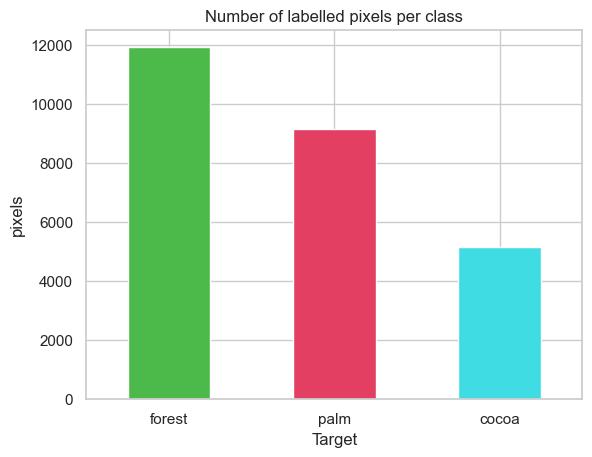

Target
forest    0.454556
palm      0.349365
cocoa     0.196079
Name: count, dtype: float64

In [28]:
id_to_labels = {0: "forest", 1: "cocoa", 2: "palm"}

pixel_targets = raw_train_df.groupby("ID")["Target"].first().astype(int)
class_counts = pixel_targets.value_counts().rename(index=id_to_labels)

ax = class_counts.plot(kind="bar", color=["#4CBA4B", "#E33F62", "#3FDDE3"], rot=0)
ax.set_title("Number of labelled pixels per class")
ax.set_ylabel("pixels")
plt.show()

class_counts / class_counts.sum()


### 2.3 Missing values

Satellite time series are full of gaps (clouds, sensor outages). Two different
things to check: **per-column** missingness, and **entirely empty timestamps**.


In [29]:
missing_share = (
    raw_train_df.drop(columns=["ID", "time", "Target"])
    .isna()
    .mean()
    .sort_values(ascending=False)
)
missing_share.to_frame("missing_share").style.format("{:.1%}")


,missing_share
NDMI,31.1%
Cirrus,31.1%
NDVI,31.1%
SWIR1,31.1%
Blue,31.1%
NDWI,31.1%
NIR,31.1%
Green,31.1%
CI,31.1%
RED,31.1%


In [30]:
feature_cols_all = [c for c in raw_train_df.columns if c not in ("ID", "time", "Target")]
empty_rows = raw_train_df[feature_cols_all].isna().all(axis=1)
print(f"Timestamps where *every* measurement is missing: {empty_rows.mean():.1%} of rows")


Timestamps where *every* measurement is missing: 31.0% of rows


### 2.4 Time coverage

How many days of history does a pixel span? Large differences between pixels
mean we cannot assume a fixed-length time series for everyone.


In [31]:
time_range = raw_train_df.groupby("ID")["time"].agg(["min", "max"])
time_range["days"] = (time_range["max"] - time_range["min"]).dt.days
time_range["days"].describe()


count    26219.000000
mean      1395.095503
std          6.576834
min        335.000000
25%       1395.000000
50%       1395.000000
75%       1395.000000
max       1398.000000
Name: days, dtype: float64

### 2.5 Class signatures

Before engineering anything, look at the raw signal: do forest, cocoa and palm
trace out visibly different curves? `NDVI` (greenness) and `NDMI` (moisture)
are good candidates — seasonal differences here are exactly what a model can
exploit.


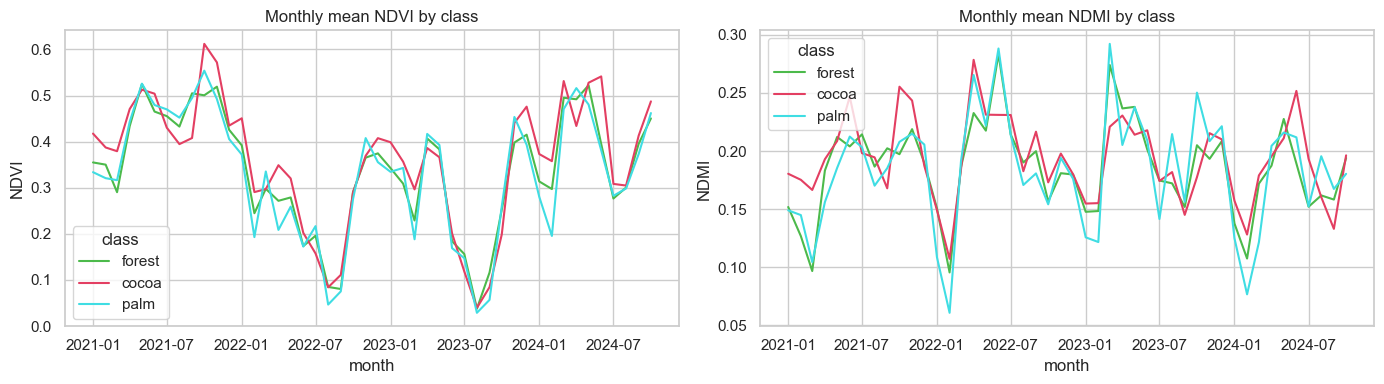

In [32]:
monthly = (
    raw_train_df.assign(month=raw_train_df["time"].dt.to_period("M").dt.to_timestamp())
    .groupby(["Target", "month"])[["NDVI", "NDMI"]]
    .mean()
    .reset_index()
)
monthly["class"] = monthly["Target"].astype(int).map(id_to_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, index in zip(axes, ["NDVI", "NDMI"]):
    sns.lineplot(
        data=monthly, x="month", y=index, hue="class",
        palette=["#4CBA4B", "#E33F62", "#3FDDE3"], ax=ax,
    )
    ax.set_title(f"Monthly mean {index} by class")
plt.tight_layout()
plt.show()


### Key takeaways

Write yours down after running — a good EDA section ends with conclusions, not
just charts. Ours:

- The classes are **imbalanced** → stratified validation, class weights later.
- Many timestamps are **completely empty** → we must fill gaps per pixel.
- Pixels have **irregular, unevenly spaced observations** → we need a regular
  time grid before we can compare pixels to each other.
- The classes show **different seasonal curves** → time-aware features should
  beat a plain average over time.


## 3. Data Preprocessing 🪥 🔢 ⏳

Two rules keep us honest:

1. **Fill gaps within each pixel only.** Forward/backward fill must never bleed
   values from one pixel into another — that would be a subtle form of leakage.
2. **Any statistic learned from data (e.g. a median) is fit on the train set
   only** and then applied to test. The test set must never teach us anything.

We also avoid looping over pixels in Python (`for group in grouped: ...`);
vectorised `groupby` operations do the same job orders of magnitude faster.


In [33]:
BAND_COLUMNS = [
    "Green", "Blue", "RED", "NIR", "SWIR1", "SWIR2",
    "Red_Edge", "Aerosols", "Red_Edge_2", "Red_Edge_3",
    "Red_Edge_4", "Water_vapor", "Cirrus",
]
PROVIDED_INDEX_COLUMNS = ["NDVI", "NDMI", "NDWI", "CI"]
FEATURE_COLUMNS = BAND_COLUMNS + PROVIDED_INDEX_COLUMNS

# Optional fast path for demos: subsample pixels BEFORE the expensive gap-filling
if QUICK_RUN:
    pixel_target_map = raw_train_df.groupby("ID")["Target"].first()
    keep_ids = (
        pixel_target_map.reset_index()
        .groupby("Target", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), N_SAMPLE_TRAIN_IDS // 3), random_state=RANDOM_STATE))["ID"]
    )
    raw_train_df = raw_train_df[raw_train_df["ID"].isin(keep_ids)]
    raw_test_df = raw_test_df[raw_test_df["ID"].isin(raw_test_df["ID"].unique()[: N_SAMPLE_TRAIN_IDS // 2])]
    print(f"QUICK_RUN: {len(keep_ids):,} train / {raw_test_df['ID'].nunique():,} test pixels")


def fill_gaps_within_pixel(df, columns):
    """Backward/forward fill *within each pixel* so values never leak across IDs.

    Two separate groupby passes (bfill, then ffill) keep every fill inside its
    pixel's boundaries, and filling one column at a time keeps peak memory at
    a single column rather than a full float64 copy of this multi-million-row
    dataset.
    """
    df = df.sort_values(["ID", "time"]).reset_index(drop=True)
    for col in columns:
        df[col] = df.groupby("ID")[col].bfill()
        df[col] = df.groupby("ID")[col].ffill()
    return df


train_df = fill_gaps_within_pixel(raw_train_df, FEATURE_COLUMNS)
test_df = fill_gaps_within_pixel(raw_test_df, FEATURE_COLUMNS)

# A pixel can still have an entirely empty column -> fall back to the TRAIN median
train_medians = train_df[FEATURE_COLUMNS].median()
train_df[FEATURE_COLUMNS] = train_df[FEATURE_COLUMNS].fillna(train_medians)
test_df[FEATURE_COLUMNS] = test_df[FEATURE_COLUMNS].fillna(train_medians)

print("Remaining NaNs -> train:", train_df[FEATURE_COLUMNS].isna().sum().sum(),
      "| test:", test_df[FEATURE_COLUMNS].isna().sum().sum())


Remaining NaNs -> train: 0 | test: 0


## 4. Feature Engineering ⚙ 🧰 ⚡

We build **two feature sets** so we can later isolate the effect of feature
engineering:

- **Route A — summary statistics**: collapse each pixel's whole history into
  mean/std/min/max per column. Simple, fast, throws away all time structure.
- **Route B — regular time grid + vegetation indices**: bin observations into
  regular 10-day composites, add domain-informed spectral indices with
  [spyndex](https://github.com/awesome-spectral-indices/spyndex), and pivot to a
  wide table where each column is *"feature at timestep t"*.


### Route A : Per-pixel summary statistics (baseline features)


In [34]:
def build_summary_features(df, columns):
    """Collapse each pixel's time series into simple summary statistics."""
    agg = df.groupby("ID")[columns].agg(["mean", "std", "min", "max"])
    agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
    return agg


train_features_a = build_summary_features(train_df, FEATURE_COLUMNS)
test_features_a = build_summary_features(test_df, FEATURE_COLUMNS)

# std of a single-observation pixel is NaN -> fill with TRAIN medians again
a_medians = train_features_a.median()
train_features_a = train_features_a.fillna(a_medians)
test_features_a = test_features_a.fillna(a_medians)

# Pixel-level target, aligned with the feature tables
y_train = train_df.groupby("ID")["Target"].first().astype(int)
y_train = y_train.reindex(train_features_a.index)

train_features_a.shape, test_features_a.shape, y_train.shape


((26219, 68), (16960, 68), (26219,))

### Route B : Regular time grid + vegetation indices

**Step 1 : Resample to 10-day composites.** Pixels observe at irregular dates;
binning to a fixed grid makes pixels comparable and smooths noise. We take the
*last* observation inside each 10-day bin, then fill empty bins within the same
pixel.


In [35]:
def resample_to_regular_grid(df, columns, rule="10D"):
    """Bin each pixel's irregular observations into regular `rule`-sized composites."""
    resampled = (
        df.groupby("ID")
        .resample(rule, on="time")
        .last()
        .drop(columns=["ID"], errors="ignore")  # group key already lives in the index
        .dropna(how="all")                      # bins with no observation at all
        .reset_index()
    )
    # Fill empty bins within the same pixel only
    resampled[columns] = resampled.groupby("ID")[columns].transform(lambda g: g.ffill().bfill())
    return resampled


train_grid = resample_to_regular_grid(train_df, FEATURE_COLUMNS + ["Target"])
test_grid = resample_to_regular_grid(test_df, FEATURE_COLUMNS)

train_grid.shape, test_grid.shape


((3670554, 20), (2374400, 19))

**Step 2 : Add vegetation indices.** Indices like `EVI`, `SAVI` or `S2REP`
combine bands in ways remote-sensing research has found discriminative for
vegetation type and canopy structure. `spyndex` computes them by name from a
standardised catalogue. (Run `spx.indices` to browse everything available.)

For further reference on spectral indices relevant for remote sensing applications, [Awesome Spectral Indices](https://awesome-spectral-indices.github.io/awesome-spectral-indices/) does a very good job of cataloguing them with thorough scientific grounding.


In [36]:
DERIVED_INDICES = ["BI", "CSI", "AVI", "SAVI", "EVI", "IRECI", "MCARI", "GNDVI", "S2REP"]


def add_spectral_indices(df):
    """Append spyndex vegetation indices computed from the raw bands."""
    indices = spx.computeIndex(
        index=DERIVED_INDICES,
        params={
            "R": df["RED"], "B": df["Blue"], "G": df["Green"], "N": df["NIR"],
            "RE1": df["Red_Edge"], "RE2": df["Red_Edge_2"], "RE3": df["Red_Edge_3"],
            "S1": df["SWIR1"], "S2": df["SWIR2"],
            "g": 2.5, "C1": 6.0, "C2": 7.5, "L": 0.5,
        },
    )
    return pd.concat([df.reset_index(drop=True), indices.reset_index(drop=True)], axis=1)


train_grid = add_spectral_indices(train_grid)
test_grid = add_spectral_indices(test_grid)

train_grid[["ID", "time", "NDVI", "EVI", "S2REP"]].head()


,ID,time,NDVI,EVI,S2REP
0,1D_0000,2021-01-04,0.544531,1.267273,729.984043
1,1D_0000,2021-01-14,0.300733,1.177785,733.374761
2,1D_0000,2021-01-24,0.404328,1.124809,733.048246
3,1D_0000,2021-02-03,0.456917,1.273440,730.242196
4,1D_0000,2021-02-13,0.409710,1.544298,729.843381


**Step 3 : Pivot wide.** We index timesteps *backwards from the most recent
composite* (`t01` = latest), so every pixel's columns line up on recency even
though their histories have different lengths. 

Each pixel becomes one row of
`feature_timestep` columns, the tabular format tree models expect.


In [37]:
GRID_FEATURE_COLUMNS = FEATURE_COLUMNS + DERIVED_INDICES
MAX_TIMESTEPS = 40  # keep the 40 most recent 10-day composites per pixel


def build_wide_features(df, max_timesteps=MAX_TIMESTEPS):
    """Pivot the regular grid to one row per pixel: feature x timestep columns."""
    df = df.sort_values(["ID", "time"]).copy()
    # timestep 1 = most recent composite, so pixels align on recency
    df["timestep"] = df.groupby("ID").cumcount(ascending=False) + 1
    df = df[df["timestep"] <= max_timesteps]
    wide = df.pivot(index="ID", columns="timestep", values=GRID_FEATURE_COLUMNS)
    wide.columns = [f"{col}_t{t:02d}" for col, t in wide.columns]
    return wide


train_features_b = build_wide_features(train_grid)
test_features_b = build_wide_features(test_grid)

# Indices can produce inf/NaN (e.g. division by ~0) -> clean, align, median-fill
train_features_b = train_features_b.replace([np.inf, -np.inf], np.nan)
test_features_b = test_features_b.replace([np.inf, -np.inf], np.nan)
test_features_b = test_features_b.reindex(columns=train_features_b.columns)

b_medians = train_features_b.median()
train_features_b = train_features_b.fillna(b_medians)
test_features_b = test_features_b.fillna(b_medians)

assert train_features_b.index.equals(y_train.index), "features and target misaligned"

train_features_b.shape, test_features_b.shape


((26219, 1040), (16960, 1040))

## 5. Modelling 💻 🧠

The competition metric is **accuracy** (always confirm on the competition page, it thus drives every choice below).

### Our evaluation protocol

Before any model, decide **how you will measure**. We use two tiers:

1. **A locked hold-out set** (20% of pixels). It stays untouched while we
   experiment and is used *once* at the end to confirm the winning approach.
2. **Stratified K-fold cross-validation** on the remaining *dev* pixels. Every
   experiment and every tuning decision below is measured this way.

Both splits happen at **pixel level** — rows belonging to the same pixel must
never straddle train and validation, or the model would be tested on pixels it
has already seen (leakage).


In [38]:
dev_ids, holdout_ids = train_test_split(
    y_train.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

X_dev_a, X_hold_a = train_features_a.loc[dev_ids], train_features_a.loc[holdout_ids]
X_dev_b, X_hold_b = train_features_b.loc[dev_ids], train_features_b.loc[holdout_ids]
y_dev, y_hold = y_train.loc[dev_ids], y_train.loc[holdout_ids]

print(f"dev pixels: {len(dev_ids):,} | locked hold-out pixels: {len(holdout_ids):,}")


dev pixels: 20,975 | locked hold-out pixels: 5,244


### Why *stratified* K-fold? Two small demonstrations

**Demo 1 — stratification keeps the class ratio in every fold.** With the
imbalance we found in section 2.2, plain `KFold` can produce folds where a
class is over- or under-represented, so each fold measures a slightly different
problem. `StratifiedKFold` forces every fold to mirror the full-data class
ratio:


In [39]:
def fold_class_shares(splitter, X, y):
    """Class share per validation fold, as a small table."""
    rows = []
    for fold, (_, val_idx) in enumerate(splitter.split(X, y), start=1):
        share = y.iloc[val_idx].value_counts(normalize=True).sort_index()
        rows.append(share.rename(index=id_to_labels).rename(f"fold {fold}"))
    return pd.DataFrame(rows)


pd.concat(
    {
        "StratifiedKFold": fold_class_shares(
            StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), X_dev_a, y_dev
        ),
        "KFold (no shuffle)": fold_class_shares(KFold(n_splits=5), X_dev_a, y_dev),
    }
).round(3)


Target                     forest  cocoa   palm
StratifiedKFold    fold 1   0.455  0.196  0.349
                   fold 2   0.455  0.196  0.349
                   fold 3   0.454  0.196  0.349
                   fold 4   0.455  0.196  0.349
                   fold 5   0.455  0.196  0.349
KFold (no shuffle) fold 1   0.446  0.189  0.365
                   fold 2   0.467  0.194  0.339
                   fold 3   0.458  0.208  0.334
                   fold 4   0.450  0.194  0.356
                   fold 5   0.452  0.195  0.353

**Demo 2 — one split is an opinion, K-fold is a consensus.** Score the *same*
model on five different single hold-out splits and you get five different
answers — which one do you trust when deciding between experiments? K-fold
averages over several splits and reports a spread, so small score differences
can be judged against the noise.


In [40]:
demo_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
)

# (a) Same model, five different single splits -> five different answers
holdout_scores = []
for seed in range(5):
    X_s, X_h, y_s, y_h = train_test_split(
        X_dev_a, y_dev, test_size=0.2, random_state=seed, stratify=y_dev
    )
    holdout_scores.append(accuracy_score(y_h, demo_model.fit(X_s, y_s).predict(X_h)))

# (b) Stratified K-fold -> one stable estimate with a spread
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_demo_scores = cross_val_score(demo_model, X_dev_a, y_dev, cv=skf, scoring="accuracy", n_jobs=-1)

print(f"5 single-split scores : {[round(float(s), 4) for s in holdout_scores]}")
print(f"  spread (max - min)  : {max(holdout_scores) - min(holdout_scores):.4f}")
print(f"5-fold CV scores      : {[round(float(s), 4) for s in cv_demo_scores]}")
print(f"  mean +/- std        : {cv_demo_scores.mean():.4f} +/- {cv_demo_scores.std():.4f}")


5 single-split scores : [0.9213, 0.9218, 0.9254, 0.9282, 0.9337]
  spread (max - min)  : 0.0124
5-fold CV scores      : [0.9197, 0.9313, 0.928, 0.9242, 0.9294]
  mean +/- std        : 0.9265 +/- 0.0042


### The experiment toolkit

Two helpers keep every experiment comparable:

- `cross_validated_accuracy` — the *same* stratified K-fold protocol for all.
- `log_experiment` — appends a row to our **Experiment Log** so we never lose
  track of what we tried and what it scored.

**Note** : While more mature professional grade workflow/experiment tooling suites such as [MLFlow](https://mlflow.org/docs/latest/) or [Weights and Biases](https://wandb.ai/site) are recommended, we use the `EXPERIMENT_LOG` for demonstrational purposes. 


In [41]:
EXPERIMENT_LOG = []


def log_experiment(version, change, features, model, cv_mean, cv_std, notes=""):
    """Record one experiment so results stay comparable and honest."""
    EXPERIMENT_LOG.append(
        {
            "version": version,
            "change": change,
            "features": features,
            "model": model,
            "cv_accuracy": round(cv_mean, 4),
            "cv_std": round(cv_std, 4),
            "notes": notes,
        }
    )
    return pd.DataFrame(EXPERIMENT_LOG)


def cross_validated_accuracy(model, X, y, n_splits=CV_FOLDS):
    """Mean/std accuracy over stratified folds — one protocol for all experiments."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
    return scores.mean(), scores.std()


### Experiment v0.1
#### Baseline: multinomial logistic regression

Always start with the simplest model that could possibly work.

**Multinomial logistic regression** is exactly that for multi-class problems:
a linear model whose per-class coefficients you can read and sanity-check. 
While its primary job may not _ALWAYS_ be to win, it provides a **reference point** every later experiment must
beat, and it smoke-tests the whole pipeline end to end.

Two details, both about *leakage in the small*:

- Linear models need features on comparable scales, unlike trees, hence the need for
  `StandardScaler`.
- The scaler lives **inside the pipeline**, so during cross-validation it is
  re-fit on each fold's training data only. Scaling the full dataset *before*
  splitting leaks validation information into training.
- `class_weight="balanced"` counters the imbalance from [section 2.2](#22-class-balance), it costs
  us nothing and saves the minority classes from being ignored.


In [42]:
logreg_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
)
mean_lr, std_lr = cross_validated_accuracy(logreg_baseline, X_dev_a, y_dev)

log_experiment(
    "v0.1", "Baseline",
    "Route A: per-pixel summary stats", "Multinomial logistic regression",
    mean_lr, std_lr,
    notes="Simple, interpretable linear model — the reference point to beat",
)


,version,change,features,model,cv_accuracy,cv_std,notes
0,v0.1,Baseline,Route A: per-pixel summary stats,Multinomial logistic regression,0.9241,0.0036,"Simple, interpretable linear model — the refer..."


### Experiment v0.2 
#### Same features, stronger model

Change **exactly one thing**: swap the linear model for a Random Forest, which
can learn non-linear boundaries and feature interactions.

Same features, same CV protocol, in this way,  any score change is attributable to model capacity alone.


In [43]:
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
mean_rf_a, std_rf_a = cross_validated_accuracy(rf_baseline, X_dev_a, y_dev)

log_experiment(
    "v0.2", "Random Forest instead of logistic regression",
    "Route A: per-pixel summary stats", "RandomForest (defaults)",
    mean_rf_a, std_rf_a,
    notes="Only the model changed — isolates the effect of model capacity",
)


,version,change,features,model,cv_accuracy,cv_std,notes
0,v0.1,Baseline,Route A: per-pixel summary stats,Multinomial logistic regression,0.9241,0.0036,"Simple, interpretable linear model — the refer..."
1,v0.2,Random Forest instead of logistic regression,Route A: per-pixel summary stats,RandomForest (defaults),0.9990,0.0007,Only the model changed — isolates the effect o...


### Experiment v0.3
#### Same model, better features

Next lever: the **features**. 
We keep the v0.2 model untouched, feed it the Route B time-grid features instead of the summary statistics. 

If the seasonal structure we saw in [section 2.5](#25-class-signatures) matters, this is where it should pay off.


In [44]:
rf_engineered = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
mean_rf_b, std_rf_b = cross_validated_accuracy(rf_engineered, X_dev_b, y_dev)

log_experiment(
    "v0.3", "Time grid + vegetation indices",
    "Route B: 10-day composites, wide", "RandomForest (defaults)",
    mean_rf_b, std_rf_b,
    notes="Only the features changed — isolates the feature-engineering effect",
)


,version,change,features,model,cv_accuracy,cv_std,notes
0,v0.1,Baseline,Route A: per-pixel summary stats,Multinomial logistic regression,0.9241,0.0036,"Simple, interpretable linear model — the refer..."
1,v0.2,Random Forest instead of logistic regression,Route A: per-pixel summary stats,RandomForest (defaults),0.9990,0.0007,Only the model changed — isolates the effect o...
2,v0.3,Time grid + vegetation indices,"Route B: 10-day composites, wide",RandomForest (defaults),0.9994,0.0002,Only the features changed — isolates the featu...


### Experiment v0.4
#### Optuna-tuned XGBoost, with K-fold inside the objective

Final lever: **model + hyperparameters**. Gradient boosting usually wins on
tabular data, but only once tuned, and *how* you score each trial matters as
much as the search itself.

This is where stratified K-fold pairs with Optuna:

- **Tuning against a single split** optimises hyperparameters for *that one
  lucky/unlucky partition*; Demo 2 above showed how much a single split can
  move. You can "win" trials by overfitting the split and not exactly the problem.
- **Tuning against the K-fold mean** gives Optuna a low-noise signal per trial,
  so the search spends its budget on hyperparameters that generalise across
  partitions. It costs $K \times$ more compute per trial, that is the price, we should be willing to pay, for a
  trustworthy signal, and why `N_OPTUNA_TRIALS` exists as a budget knob.

One honest caveat: because we tune on these folds, the tuning CV score itself is
slightly optimistic. 

That is exactly why we locked away the hold-out set — it
delivers the final, unbiased confirmation in [section 6](#6-model-evaluation---).

A detail worth copying into your own practice: **actually use the class
weights**. 

In [45]:
def train_xgb(X, y, params, num_boost_round=TUNING_BOOST_ROUNDS):
    """Train XGBoost with balanced class weights recomputed from the given labels."""
    classes = np.unique(y)
    weight_of = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y)))
    row_weights = np.array([weight_of[c] for c in y])
    return xgb.train(
        params, xgb.DMatrix(X, label=y, weight=row_weights),
        num_boost_round=num_boost_round,
    )


def xgb_cv_objective(trial):
    """Optuna objective: mean accuracy over stratified folds (low-noise signal)."""
    params = {
        "objective": "multi:softmax",
        "num_class": y_dev.nunique(),
        "tree_method": "gpu_hist" if DEVICE=="cuda" else "hist",
        "random_state": RANDOM_STATE,
        "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    for fold_tr, fold_va in skf.split(X_dev_b, y_dev):
        model = train_xgb(X_dev_b.iloc[fold_tr], y_dev.iloc[fold_tr], params)
        preds = model.predict(xgb.DMatrix(X_dev_b.iloc[fold_va]))
        fold_scores.append(accuracy_score(y_dev.iloc[fold_va], preds))
    trial.set_user_attr("fold_std", float(np.std(fold_scores)))
    return float(np.mean(fold_scores))


study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(xgb_cv_objective, n_trials=N_OPTUNA_TRIALS)

study.best_params


{'learning_rate': 0.10547256389799264,
 'max_depth': 3,
 'min_child_weight': 1.419752601151064,
 'gamma': 0.4355325055291152,
 'subsample': 0.8933139358849993,
 'colsample_bytree': 0.7883097793305054}

In [46]:
best_params = {
    **study.best_params,
    "objective": "multi:softmax",
    "num_class": y_train.nunique(),
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
}

log_experiment(
    "v0.4", "Optuna-tuned XGBoost + class weights",
    "Route B: 10-day composites, wide", "XGBoost (tuned with CV objective)",
    study.best_value, study.best_trial.user_attrs["fold_std"],
    notes=f"{N_OPTUNA_TRIALS} trials x {CV_FOLDS} folds; tuning CV is slightly optimistic — hold-out decides",
)


,version,change,features,model,cv_accuracy,cv_std,notes
0,v0.1,Baseline,Route A: per-pixel summary stats,Multinomial logistic regression,0.9241,0.0036,"Simple, interpretable linear model — the refer..."
1,v0.2,Random Forest instead of logistic regression,Route A: per-pixel summary stats,RandomForest (defaults),0.9990,0.0007,Only the model changed — isolates the effect o...
2,v0.3,Time grid + vegetation indices,"Route B: 10-day composites, wide",RandomForest (defaults),0.9994,0.0002,Only the features changed — isolates the featu...
3,v0.4,Optuna-tuned XGBoost + class weights,"Route B: 10-day composites, wide",XGBoost (tuned with CV objective),1.0000,0.0000,40 trials x 5 folds; tuning CV is slightly opt...


## 6. Model Evaluation 🧪 🔬 🔎

First the headline: did each version actually improve on the last? Read the
`cv_std` column too — an "improvement" smaller than the noise is not an
improvement.


In [47]:
experiment_log = pd.DataFrame(EXPERIMENT_LOG)
experiment_log


,version,change,features,model,cv_accuracy,cv_std,notes
0,v0.1,Baseline,Route A: per-pixel summary stats,Multinomial logistic regression,0.9241,0.0036,"Simple, interpretable linear model — the refer..."
1,v0.2,Random Forest instead of logistic regression,Route A: per-pixel summary stats,RandomForest (defaults),0.9990,0.0007,Only the model changed — isolates the effect o...
2,v0.3,Time grid + vegetation indices,"Route B: 10-day composites, wide",RandomForest (defaults),0.9994,0.0002,Only the features changed — isolates the featu...
3,v0.4,Optuna-tuned XGBoost + class weights,"Route B: 10-day composites, wide",XGBoost (tuned with CV objective),1.0000,0.0000,40 trials x 5 folds; tuning CV is slightly opt...


### The moment of truth: the locked hold-out

All four experiments were compared and tuned on the dev folds. Now — and only
now — we retrain the winning configuration on **all dev data** and score it
**once** on the hold-out pixels it has never seen or influenced.

Compare this number to v0.4's CV score: if they are close, our protocol was
honest; if the hold-out is much worse, something leaked or we overfit the CV.


Hold-out accuracy: 1.0000
(v0.4 tuning CV was 1.0000 — expect a small, explainable gap)

              precision    recall  f1-score   support

      forest       1.00      1.00      1.00      2384
       cocoa       1.00      1.00      1.00      1028
        palm       1.00      1.00      1.00      1832

    accuracy                           1.00      5244
   macro avg       1.00      1.00      1.00      5244
weighted avg       1.00      1.00      1.00      5244



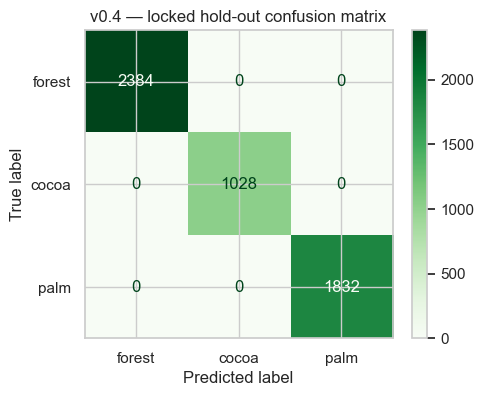

In [48]:
holdout_model = train_xgb(X_dev_b, y_dev, best_params)
hold_preds = holdout_model.predict(xgb.DMatrix(X_hold_b))
class_names = [id_to_labels[i] for i in sorted(id_to_labels)]

print(f"Hold-out accuracy: {accuracy_score(y_hold, hold_preds):.4f}")
print(f"(v0.4 tuning CV was {study.best_value:.4f} — expect a small, explainable gap)\n")
print(classification_report(y_hold, hold_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_hold, hold_preds), display_labels=class_names
).plot(ax=ax, cmap="Greens")
plt.title("v0.4 — locked hold-out confusion matrix")
plt.show()


Then dig into *where* the model still fails and *what* it relies on — both are
idea generators for the next experiment.


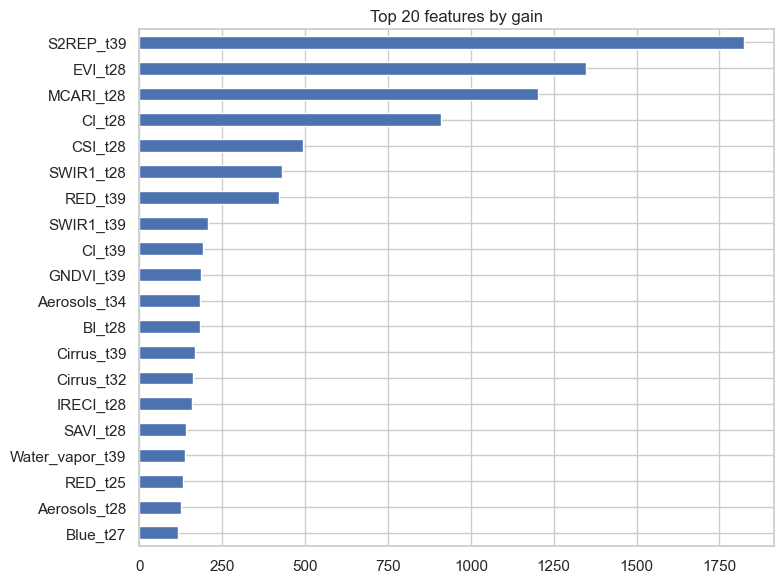

In [49]:
importance = (
    pd.Series(holdout_model.get_score(importance_type="gain"))
    .sort_values(ascending=False)
    .head(20)
)
importance.iloc[::-1].plot(
    kind="barh", figsize=(8, 6), title="Top 20 features by gain"
)
plt.tight_layout()
plt.show()


Questions to ask yourself here:

- Which class pair is confused most, and *why* might that be physically?
- Do the top features cluster around particular timesteps or indices? That
  hints at which part of the season carries the signal.
- How big was the CV-to-hold-out gap? A large gap says your iteration protocol
  needs fixing before your model does.


## 7. Submission 📤

The hold-out confirmed the approach, so for the final model we **retrain on
100% of the training data** (dev + hold-out — more data, better model; the
honest score estimate is already banked), predict the test pixels, and validate
the file *before* uploading:

- exactly the columns `ID,Target`
- exactly one row per test pixel
- only valid class labels


In [50]:
final_model = train_xgb(train_features_b, y_train, best_params)
test_preds = final_model.predict(xgb.DMatrix(test_features_b)).astype(int)

submission = pd.DataFrame({"ID": test_features_b.index, "Target": test_preds})

assert list(submission.columns) == ["ID", "Target"]
assert QUICK_RUN or submission["ID"].nunique() == raw_test_df["ID"].nunique()
assert submission["Target"].isin([0, 1, 2]).all()

submission.head()


,ID,Target
0,1D_0005,0
1,1D_000A,0
2,1D_000D,0
3,1D_000E,0
4,1D_0015,0


In [51]:
# Naming files with a timestamp keeps every submission reproducible and trackable
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sub_filename = SUBMISSIONS_DIR / f"xgb_{timestamp}.csv"

submission.to_csv(sub_filename, index=False)
print(f"Saved {len(submission):,} rows -> {sub_filename}")


Saved 16,960 rows -> D:\Projects\ds_ml_ai\zindi\challenges\amini-canopy-or-crop-challenge\reports\zindi_submissions\xgb_20260917_172939.csv


Upload the CSV on the competition page, and **record the leaderboard score in
the experiment log too** — the gap between your CV/hold-out score and the
leaderboard is itself information (overfitting, distribution shift, ...).


## 8. Where to Go Next 🚀

Ideas for v0.5+, roughly cheapest-first. Add each as a row in the experiment
log, change one thing at a time, and keep the ones that beat v0.4:

1. **More features**: browse `spx.indices` for other indices; add seasonal
   aggregates (rainy vs dry season means); increase `MAX_TIMESTEPS`.
2. **Better tuning**: more Optuna trials; tune `num_boost_round` with early
   stopping *inside each fold*; try `optuna.visualization` to inspect the
   search.
3. **Stronger single models**: LightGBM / CatBoost with the same CV protocol.
4. **Ensembling**: average predictions of the RF and XGBoost models (or stack
   them).
5. **Time-series models**: sequence models (e.g. a small transformer or LSTM
   over the regular grid) once the tabular approaches plateau.

### References

- [Competition page](https://zindi.world/competitions/amini-canopy-or-crop-challenge)
- [Study Jam session](https://luma.com/h79sb3iz) ·
  [discussion thread](https://zindi.world/competitions/amini-canopy-or-crop-challenge-september-studyjam/discussions/34804)
- [scikit-learn: cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Optuna documentation](https://optuna.readthedocs.io/)
- [spyndex — Awesome Spectral Indices](https://github.com/awesome-spectral-indices/spyndex)
- [XGBoost documentation](https://xgboost.readthedocs.io/)
